# Raspberry Pico Smoke Test

Dieses Notebook verbindet sich per USB-Serial mit einem Pico (MicroPython), laesst die LED blinken und zeichnet die interne Temperatur auf.

In [27]:
import matplotlib.pyplot as plt  # Plotten im Notebook
import subprocess
import sys

def run_on_pico(code: str, port: str = "auto", exec_timeout_s: float = 20.0):
    cmd = [sys.executable, "-m", "mpremote", "connect", port, "exec", code]
    proc = subprocess.run(cmd, capture_output=True, text=True, timeout=exec_timeout_s)
    return proc.stdout.strip(), proc.stderr.strip()

cmd = [sys.executable, "-m", "mpremote", "connect", "list"]
ports = subprocess.run(cmd, capture_output=True, text=True, timeout=10)
print(ports.stdout.strip() or "Keine Ports von mpremote erkannt.")
if ports.stderr.strip():
    print("stderr:\n", ports.stderr.strip())

COM3 E6605481DB296137 2e8a:0005 Microsoft None


In [28]:
port = "auto"
print("Using port:", port)

out, err = run_on_pico("print('hello from pico')", port=port)
print("STDOUT:\n", out)
print("STDERR:\n", err)

Using port: auto
STDOUT:
 hello from pico
STDERR:
 


Wokwi-Beispiel: https://wokwi.com/projects/300504213470839309

In [32]:
# Dieser String ist Pico-Code: Er laeuft auf dem MicroPython-Interpreter des Pico (nicht auf dem PC).
# Deshalb stehen machine/utime-Imports hier im String und nicht in der Notebook-Import-Zelle.
code = '''
from machine import Pin
from utime import sleep

sleep(0.01)
print("Hello, Pi Pico!")

try:
    led = Pin("LED", Pin.OUT)
except Exception:
    led = Pin(25, Pin.OUT)

for _ in range(20):
    led.toggle()
    sleep(0.5)
'''

out, err = run_on_pico(code, port=port, exec_timeout_s=20)
print("STDOUT:\n", out)
print("STDERR:\n", err)

STDOUT:
 Hello, Pi Pico!
STDERR:
 


t= 0.0 s | raw=14163 | temp=22.83 C
t= 0.5 s | raw=14099 | temp=24.70 C
t= 1.0 s | raw=14099 | temp=24.70 C
t= 1.5 s | raw=14099 | temp=24.70 C
t= 2.0 s | raw=14099 | temp=24.70 C
t= 2.5 s | raw=14099 | temp=24.70 C
t= 3.0 s | raw=14083 | temp=25.17 C
t= 3.5 s | raw=14099 | temp=24.70 C
t= 4.0 s | raw=14099 | temp=24.70 C
t= 4.5 s | raw=14099 | temp=24.70 C
t= 5.0 s | raw=14083 | temp=25.17 C


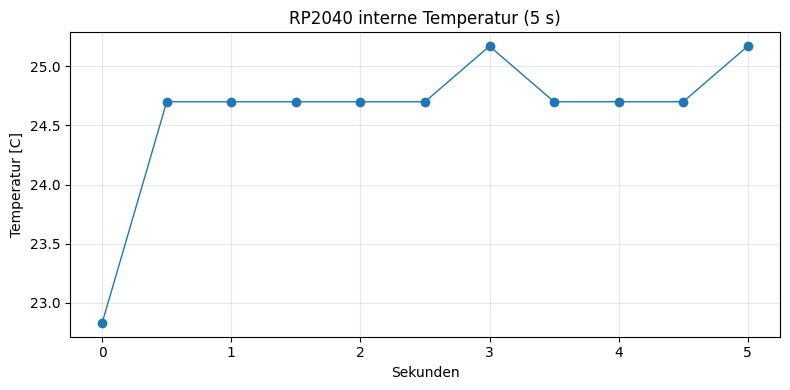

In [31]:
# 1) Messung klar konfigurieren
duration_s = 5
sample_interval_s = 0.5
sample_count = int(duration_s / sample_interval_s) + 1

# 2) Messung am Pico starten (interner RP2040-Temperatursensor)
#    Alles im String wird auf dem Pico ausgefuehrt; der Notebook-Python-Code baut nur den String.
code = f'''
from machine import ADC
from utime import sleep

sensor = ADC(4)
interval_s = {sample_interval_s}
sample_count = {sample_count}
print('t_s,raw,temp_c')
for i in range(sample_count):
    raw = sensor.read_u16()
    voltage = raw * 3.3 / 65535
    temp_c = 27 - (voltage - 0.706) / 0.001721
    t = i * interval_s
    print(f"{{t:.3f}},{{raw}},{{temp_c:.2f}}")
    sleep(interval_s)
'''

out, err = run_on_pico(code, port=port, exec_timeout_s=20)
if err.strip():
    raise RuntimeError(err)

# 3) Ausgabe einlesen und plotten
times = []
raw_values = []
temps = []
for line in out.splitlines():
    line = line.strip().lstrip('>')
    if line.startswith('OK'):
        line = line[2:].strip()
    if line == 't_s,raw,temp_c':
        continue
    if not line or ',' not in line:
        continue
    parts = line.split(',')
    if len(parts) != 3:
        continue
    try:
        t = float(parts[0])
        raw = int(parts[1])
        temp = float(parts[2])
        times.append(t)
        raw_values.append(raw)
        temps.append(temp)
    except ValueError:
        continue

for t, raw, temp in zip(times, raw_values, temps):
    print(f"t={t:>4.1f} s | raw={raw:>5d} | temp={temp:>5.2f} C")

plt.figure(figsize=(8, 4))
plt.plot(times, temps, marker='o', linewidth=1)
plt.xlabel('Sekunden')
plt.ylabel('Temperatur [C]')
plt.title(f'RP2040 interne Temperatur ({duration_s} s)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()